In [2]:
# imports
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors3D
from rdkit import RDLogger
import numpy as np
from rdkit.Chem import Descriptors
from rdkit.Chem import rdFingerprintGenerator
import matplotlib.pyplot as plt
from rdkit import DataStructs
from sklearn.decomposition import PCA

In [3]:
# setup
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

RDLogger.DisableLog('rdApp.warning')

df = pd.read_parquet("CompoundDataFuncsFingerprints.parquet")

In [4]:
# Radius of Gyration calculation:

radius_of_gyration = []
count_none = 0
for i in range(df.shape[0]):
    mol_string = df['mol3D'].iloc[i]
    mol = Chem.MolFromMolBlock(mol_string, removeHs=False, strictParsing=False, sanitize=False)
    if mol is None:
        radius_of_gyration.append(np.nan)
        count_none += 1
    else:
        radius_of_gyration.append(Descriptors3D.RadiusOfGyration(mol))

df["Radius of Gyration"] = radius_of_gyration

In [5]:
# Number of Rotatable Bonds calculation:

rot_bonds = []
count_none = 0
for i in range(df.shape[0]):
    mol = Chem.MolFromSmiles(df['SMILES'].iloc[i])
    if mol is None:
        rot_bonds.append(np.nan)
        count_none += 1
    else:
        rot_bonds.append(Descriptors.NumRotatableBonds(mol))

df["Number of Rotatable Bonds"] = rot_bonds

In [6]:
# Morgan Fingerprint calculation:

morg_prints = []
count_none = 0
for i in range(df.shape[0]):
    mol = Chem.MolFromSmiles(df['SMILES'].iloc[i])
    if mol is None:
        morg_prints.append(np.nan)
        count_none += 1
    else:
        morg_prints.append(morgan_generator.GetFingerprint(mol))

df["Morgan Fingerprints"] = morg_prints

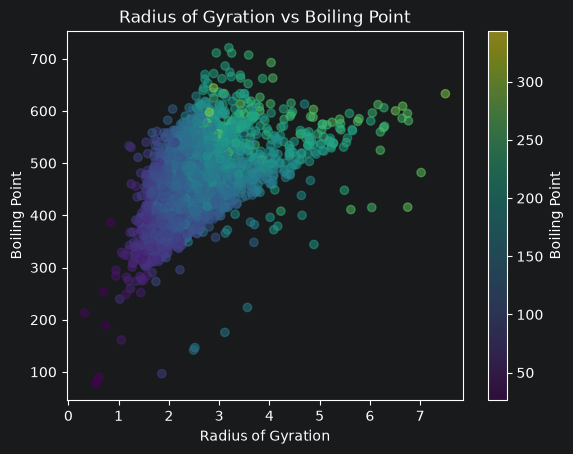

In [14]:
# Simple scatter plot for radius of gyration:

scatter = plt.scatter(df["Radius of Gyration"], df['BP'], c=df['MW'], alpha=0.5)
plt.xlabel("Radius of Gyration")
plt.ylabel("Boiling Point")
plt.title("Radius of Gyration vs Boiling Point")
plt.colorbar(scatter, label="Boiling Point")

plt.savefig('radofgyr.png')
plt.show()

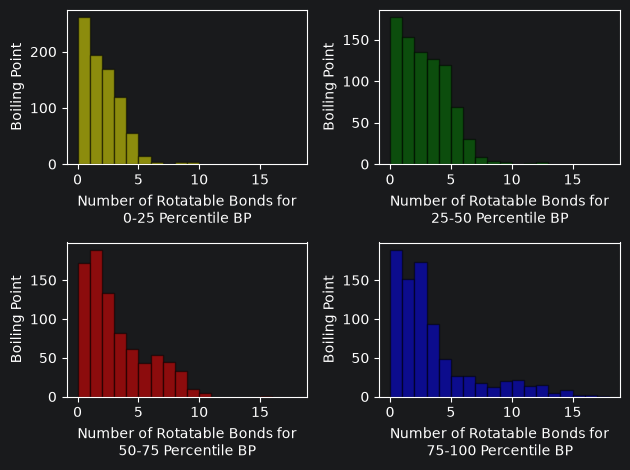

In [8]:
# Histogram set for rotatable bonds

Q1_bp = df["BP"].quantile(.25)
Q3_bp = df["BP"].quantile(.75)
median_bp = df["BP"].median()

low_bp = df[df["BP"] < Q1_bp]
low_mid_bp = df[(df["BP"] < median_bp) & (df["BP"] >= Q1_bp)]
high_mid_bp = df[(df["BP"] >= median_bp) & (df["BP"] < Q3_bp)]
high_bp = df[df["BP"] >= Q3_bp]

bin_num = range(int(df["Number of Rotatable Bonds"].max()) + 2)

plt.subplot(2,2,1)
plt.hist(low_bp["Number of Rotatable Bonds"].dropna(), bins=bin_num, alpha=0.5, color='yellow', edgecolor="black")
plt.xlabel("Number of Rotatable Bonds for\n0-25 Percentile BP")
plt.ylabel("Boiling Point")

plt.subplot(2,2,2)
plt.hist(low_mid_bp["Number of Rotatable Bonds"].dropna(), bins=bin_num, alpha=0.5, color='green', edgecolor="black")
plt.xlabel("Number of Rotatable Bonds for\n25-50 Percentile BP")
plt.ylabel("Boiling Point")

plt.subplot(2,2,3)
plt.hist(high_mid_bp["Number of Rotatable Bonds"].dropna(), bins=bin_num, alpha=0.5, color='red', edgecolor="black")
plt.xlabel("Number of Rotatable Bonds for\n50-75 Percentile BP")
plt.ylabel("Boiling Point")

plt.subplot(2,2,4)
plt.hist(high_bp["Number of Rotatable Bonds"].dropna(), bins=bin_num, alpha=0.5, color='blue', edgecolor="black")
plt.xlabel("Number of Rotatable Bonds for\n75-100 Percentile BP")
plt.ylabel("Boiling Point")

plt.tight_layout()
plt.savefig('rotbondhist.png')
plt.show()


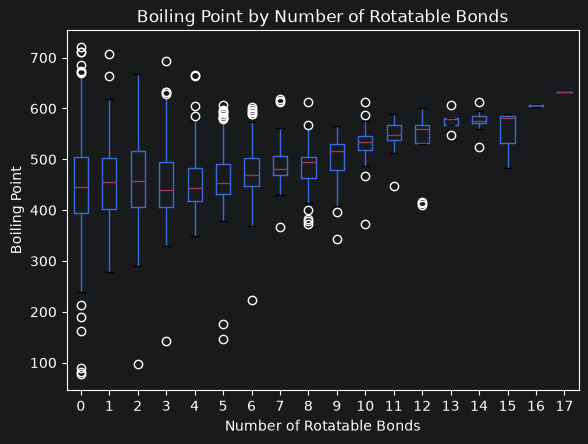

In [9]:
# boxplot as well for this one

df.boxplot(column="BP", by="Number of Rotatable Bonds", grid=False)
plt.xlabel("Number of Rotatable Bonds")
plt.ylabel("Boiling Point")
plt.title("Boiling Point by Number of Rotatable Bonds")
plt.suptitle("")
plt.savefig('rotbondbox.png')
plt.show()


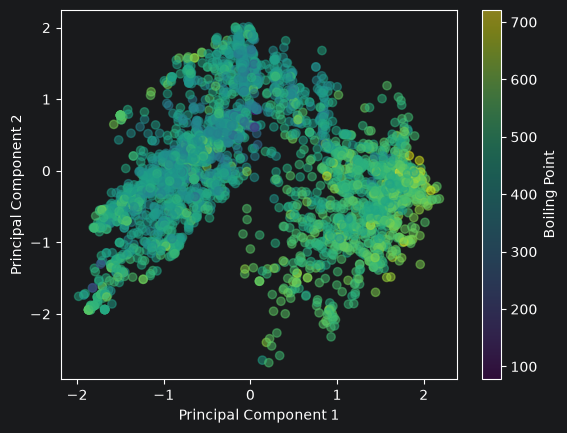

In [13]:
# Morgan fingerprint plotting
# gonna do PCA

# convert to array
fingerprint_arrays = []

for fp in df["Morgan Fingerprints"]:
    arr = np.zeros((2048,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    fingerprint_arrays.append(arr)

X = np.array(fingerprint_arrays)

# do PCA
pca = PCA(n_components=2)
fingerprint_pca = pca.fit_transform(X)

# make some more columns
df["Morgan PC1"] = fingerprint_pca[:, 0]
df["Morgan PC2"] = fingerprint_pca[:, 1]

# okay actual plotting time
scatter = plt.scatter(df["Morgan PC1"], df["Morgan PC2"], c=df["BP"], alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label="Boiling Point")

plt.savefig('morganPCA.png')
plt.show()

In [11]:
# diagnosis cell
print(df.columns)

Index(['CAS', 'MW', 'BP', 'SMILES', 'mol3D', 'Allenic', 'Vinylic', 'Arene',
       'Alcohol', 'Ether', 'Amine', 'Imine', 'Nitrile', 'Thiol', 'Sulfide',
       'Disulfide', 'Aldehyde', 'Ketone', 'CarboxylAcid', 'Ester', 'Thioester',
       'Amide', 'AcidChloride', 'Anhydride', 'Errors', 'CripA', 'CripB',
       'PartialCharge', 'Fingerprint', 'Radius of Gyration',
       'Number of Rotatable Bonds', 'Morgan Fingerprints', 'Morgan PC1',
       'Morgan PC2'],
      dtype='object')
